# 🛰️ TLE Parsing and Orbital Analysis

This notebook extracts orbital parameters from TLE data and analyzes satellite behavior.

## Reading TLE

In [10]:
file_path = "../data/active.txt"

with open(file_path, "r") as f:
    lines = f.readlines()

print("Total líneas:", len(lines))
print("Ejemplo:")
print("".join(lines[:3]))

Total líneas: 90048
Ejemplo:
CALSPHERE 1             

1 00900U 64063C   26100.14180140  .00000717  00000+0  72075-3 0  9994



## Convert data

In [11]:
def read_tles(lines):
    # limpiar líneas vacías
    lines = [l.strip() for l in lines if l.strip() != ""]
    
    sats = []
    
    for i in range(0, len(lines), 3):
        if i + 2 < len(lines):
            name = lines[i]
            l1 = lines[i+1]
            l2 = lines[i+2]
            
            # validar que sean líneas TLE reales
            if l1.startswith("1 ") and l2.startswith("2 "):
                sats.append({
                    "name": name,
                    "l1": l1,
                    "l2": l2,
                })
    
    return sats

sats = read_tles(lines)

print("Número de satélites:", len(sats))
print(sats[0])

Número de satélites: 15008
{'name': 'CALSPHERE 1', 'l1': '1 00900U 64063C   26100.14180140  .00000717  00000+0  72075-3 0  9994', 'l2': '2 00900  90.2196  70.1725 0027034 133.5737 344.6405 13.76542689 62066'}


## Parsearing orbital elements

In [12]:
def parse_tle(sat):
    l2 = sat["l2"]
    
    inclination = float(l2[8:16])
    raan = float(l2[17:25])
    eccentricity = float("0." + l2[26:33].strip())
    arg_perigee = float(l2[34:42])
    mean_anomaly = float(l2[43:51])
    mean_motion = float(l2[52:63])
    
    return {
        "name": sat["name"],
        "inclination_deg": inclination,
        "raan_deg": raan,
        "eccentricity": eccentricity,
        "arg_perigee_deg": arg_perigee,
        "mean_anomaly_deg": mean_anomaly,
        "mean_motion_rev_day": mean_motion,
    }

parsed = [parse_tle(s) for s in sats]

## Convert on a DataFrame

In [13]:
import pandas as pd

df = pd.DataFrame(parsed)
df.head()

,name,inclination_deg,raan_deg,eccentricity,arg_perigee_deg,mean_anomaly_deg,mean_motion_rev_day
0,CALSPHERE 1,90.2196,70.1725,0.002703,133.5737,344.6405,13.765427
1,CALSPHERE 2,90.2317,74.1682,0.002049,67.1617,304.0298,13.528948
2,LCS 1,32.1465,338.9003,0.001334,240.5305,119.3862,9.893100
3,TEMPSAT 1,89.9994,212.5808,0.007151,79.8068,307.8389,13.335911
4,CALSPHERE 4A,89.8977,123.1649,0.006774,295.9242,75.0305,13.362655


In [14]:
df.describe()

,inclination_deg,raan_deg,eccentricity,arg_perigee_deg,mean_anomaly_deg,mean_motion_rev_day
count,15008.000000,15008.000000,1.500800e+04,15008.000000,15008.000000,15008.000000
mean,60.050348,182.555130,2.575171e-03,163.298686,196.403620,14.326562
std,23.824569,102.630523,3.839525e-02,94.490652,94.935474,3.160637
min,0.001500,0.005400,1.000000e-07,0.009600,0.082800,0.283487
25%,43.003400,95.063750,1.177000e-04,85.349025,92.973875,14.985063
50%,53.160200,177.507150,1.519000e-04,113.951550,242.289850,15.275653
75%,86.392100,271.448150,2.919000e-04,267.344925,274.833275,15.302005
max,149.757300,359.971200,8.972572e-01,359.892400,359.992500,16.433173


## Calculating orbital periods

In [15]:
df["period_minutes"] = 1440 / df["mean_motion_rev_day"]

## Some Graphics

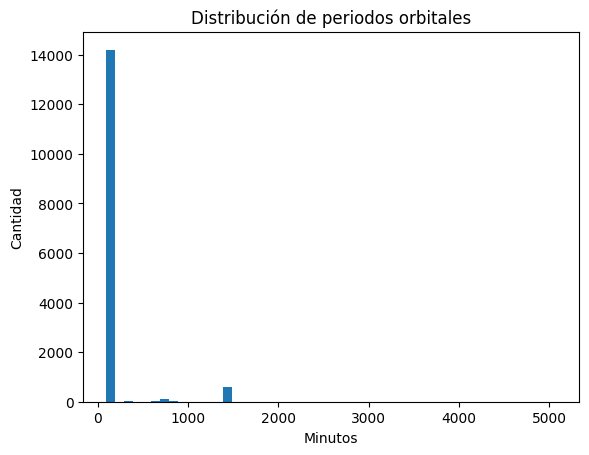

In [16]:
import matplotlib.pyplot as plt

plt.hist(df["period_minutes"], bins=50)
plt.title("Distribución de periodos orbitales")
plt.xlabel("Minutos")
plt.ylabel("Cantidad")
plt.show()

## Classify orbits

In [17]:
def classify_orbit(period):
    if period < 120:
        return "LEO"
    elif period < 1000:
        return "MEO"
    else:
        return "GEO"

df["orbit_type"] = df["period_minutes"].apply(classify_orbit)

df["orbit_type"].value_counts()

orbit_type
LEO    14191
GEO      611
MEO      206
Name: count, dtype: int64

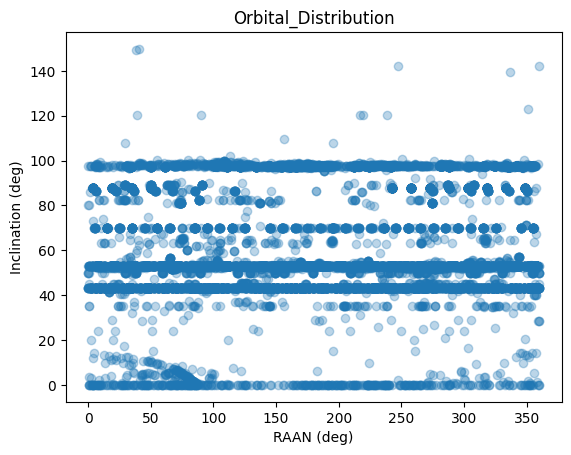

In [18]:
plt.scatter(df["raan_deg"], df["inclination_deg"], alpha=0.3)
plt.xlabel("RAAN (deg)")
plt.ylabel("Inclination (deg)")
plt.title("Orbital_Distribution")
plt.show()